## Discover Sionna

This example notebook will guide you through the basic principles and illustrates the key features of [Sionna](https://nvlabs.github.io/sionna/index.html).
With only a few commands, you can simulate the PHY-layer link-level performance for many 5G-compliant components, including easy visualization of the results.


### Load Required Packages

The Sionna python package must be [installed](https://nvlabs.github.io/sionna/installation.html).

In [11]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import torch
import numpy as np

# IPython "magic function" for inline plots
%matplotlib inline
import matplotlib.pyplot as plt

**Tip**: you can run bash commands in Jupyter via the `!` operator.

In [12]:
!nvidia-smi

Tue Mar 24 22:22:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     Off |   00000000:01:00.0  On |                  N/A |
| 27%   28C    P8             29W /  250W |    8383MiB /  11264MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In case multiple GPUs are available, we restrict this notebook to single-GPU usage. 

*Remark*: Sionna does not require a GPU. Everything can also run on your CPU - but you may need to wait a little longer.

In [13]:
print("Available devices:")
for device in sionna.phy.config.available_devices:
    print(device)

# Select the first GPU
sionna.phy.config.device = "cuda:0"

Available devices:
cpu
cuda:0


### Sionna Data-flow and Design Paradigms

Sionna inherently parallelizes simulations via *batching*, i.e., each element in the batch dimension is simulated independently.

This means the first tensor dimension is always used for *inter-frame* parallelization similar to an outer *for-loop* in Matlab/NumPy simulations.

To keep the dataflow efficient, Sionna follows a few simple design principles:

* Signal-processing components are implemented as individual [Sionna Blocks](https://nvlabs.github.io/sionna/phy/api/block.html#sionna.phy.block.Block). 
* `torch.float32` is used as preferred datatype and `torch.complex64` for complex-valued datatypes, respectively.  
This allows simpler re-use of components (e.g., the same scrambling layer can be used for binary inputs and LLR-values).
* Models can be developed in *eager mode* allowing simple (and fast) modification of system parameters.
* Number crunching simulations can be executed in the faster [compiled
  mode](https://docs.pytorch.org/tutorials/intermediate/torch_compile_tutorial.html)
  which is available for most components.
* Whenever possible, components are automatically differentiable via [auto-grad](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html) to simplify the deep learning design-flow.
* Code is structured into sub-packages for different tasks such as channel coding, mapping,... (see [API documentation](https://nvlabs.github.io/sionna/phy/api/phy.html) for details).

The division into individual blocks simplifies deployment and all blocks and functions comes with unittests to ensure their correct behavior.

These paradigms simplify the re-useability and reliability of our components for
a wide range of communications related applications.

### A note on random number generation
When Sionna is loaded, it instantiates random number generators (RNGs) for [Python](https://docs.python.org/3/library/random.html#alternative-generator),
[NumPy](https://numpy.org/doc/stable/reference/random/generator.html), and [PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.Generator.html). You can optionally set a seed which will make all of your
results deterministic, as long as only these RNGs are used. In the cell below,
you can see how this seed is set and how the different RNGs can be used.

In [14]:
sionna.phy.config.seed = 40

# Python RNG - use instead of
# import random
# random.randint(0, 10)
print(sionna.phy.config.py_rng.randint(0,10))

# NumPy RNG - use instead of
# import numpy as np
# np.random.randint(0, 10)
print(sionna.phy.config.np_rng.integers(0,10))

# PyTorch RNG - use instead of
# import torch
# torch.randint(0, 10, (1,), dtype=torch.int32)
# WHen creating a random number in PyTorch, we must specify the generator as
# well as the device on which we want to place it
print(torch.randint(0, 10, (1,), dtype=torch.int32, device=sionna.phy.config.device, generator=sionna.phy.config.torch_rng()))

7
5
tensor([7], device='cuda:0', dtype=torch.int32)


### Let's Get Started - The First Blocks (*Eager Mode*)

Every block needs to be initialized once before it can be used.

**Tip**: use the [API documentation](https://nvlabs.github.io/sionna/phy/api/phy.html) to find an overview of all existing components.

We now want to transmit some symbols over an AWGN channel.
First, we need to initialize the corresponding block.

In [15]:
channel = sionna.phy.channel.AWGN() # init AWGN channel block

In this first example, we want to add Gaussian noise to some given values of `x`.

Remember - the first dimension is the *batch-dimension*.

We simulate 2 message frames each containing 4 symbols.

*Remark*: the [AWGN channel](https://nvlabs.github.io/sionna/phy/api/channel/wireless/awgn.html#sionna.phy.channel.AWGN) is defined to be complex-valued.

In [16]:
# define a (complex-valued) tensor to be transmitted
import torch

x = torch.tensor([[0., 1.5, 1., 0.], [-1., 0., -2, 3]], dtype=torch.complex64)

# let's have look at the shape
print("Shape of x: ", x.shape)
print("Values of x: ", x)

Shape of x:  torch.Size([2, 4])
Values of x:  tensor([[ 0.0000+0.j,  1.5000+0.j,  1.0000+0.j,  0.0000+0.j],
        [-1.0000+0.j,  0.0000+0.j, -2.0000+0.j,  3.0000+0.j]])


We want to simulate the channel at an SNR of 5 dB.
For this, we can simply *call* the previously defined block `channel`.

A Sionna block acts pretty much like a function: it has an input and returns the processed output.

*Remark*: Each time this cell is executed a new noise realization is drawn.

In [17]:
ebno_db = 5

# calculate noise variance from given EbNo
no = sionna.phy.utils.ebnodb2no(ebno_db = ebno_db,
                                num_bits_per_symbol=2, # QPSK
                                coderate=1) 
y = channel(x, no)

print("Noisy symbols are: ", y)

Noisy symbols are:  tensor([[-0.0681-0.2086j,  1.5907-0.1598j,  1.0788+0.1321j,  0.2255-0.3065j],
        [-1.0517-0.1059j, -0.1310+0.2506j, -2.2642+0.4354j,  2.8913-0.1774j]],
       device='cuda:0')


### Batches and Multi-dimensional Tensors

Sionna natively supports multi-dimensional tensors.

Most blocks operate at the last dimension and can have arbitrary input shapes (preserved at output).

Let us assume we want to add a CRC-24 check to 64 codewords of length 500 (e.g., different CRC per sub-carrier).
Further, we want to parallelize the simulation over a batch of 100 samples.

In [18]:
batch_size = 100 # outer level of parallelism
num_codewords = 64 # codewords per batch sample
info_bit_length = 500 # info bits PER codeword

source = sionna.phy.mapping.BinarySource() # yields random bits

u = source([batch_size, num_codewords, info_bit_length]) # call the source layer
print("Shape of u: ", u.shape)

# initialize an CRC encoder with the standard compliant "CRC24A" polynomial
encoder_crc = sionna.phy.fec.crc.CRCEncoder("CRC24A")
decoder_crc = sionna.phy.fec.crc.CRCDecoder(encoder_crc) # connect to encoder

# add the CRC to the information bits u
c = encoder_crc(u) # returns a list [c, crc_valid]
print("Shape of c: ", c.shape)
print("Processed bits: ", c.numel())

# we can also verify the results
# returns list of [info bits without CRC bits, indicator if CRC holds]
u_hat, crc_valid = decoder_crc(c) 
print("Shape of u_hat: ", u_hat.shape)
print("Shape of crc_valid: ", crc_valid.shape)

print("Valid CRC check of first codeword: ", crc_valid[0,0,0])

Shape of u:  torch.Size([100, 64, 500])
Shape of c:  torch.Size([100, 64, 524])
Processed bits:  3353600
Shape of u_hat:  torch.Size([100, 64, 500])
Shape of crc_valid:  torch.Size([100, 64, 1])
Valid CRC check of first codeword:  tensor(True, device='cuda:0')


We want to do another simulation but for 5 independent users.

Instead of defining 5 different tensors, we can simply add another dimension.

In [19]:
num_users = 5

u = source([batch_size, num_users, num_codewords, info_bit_length]) 
print("New shape of u: ", u.shape)

# We can re-use the same encoder as before
c = encoder_crc(u)
print("New shape of c: ", c.shape)
print("Processed bits: ", c.numel())

New shape of u:  torch.Size([100, 5, 64, 500])
New shape of c:  torch.Size([100, 5, 64, 524])
Processed bits:  16768000


Often a good visualization of results helps to get new research ideas.
Thus, Sionna has built-in plotting functions.

Let's have look at a 16-QAM constellation.

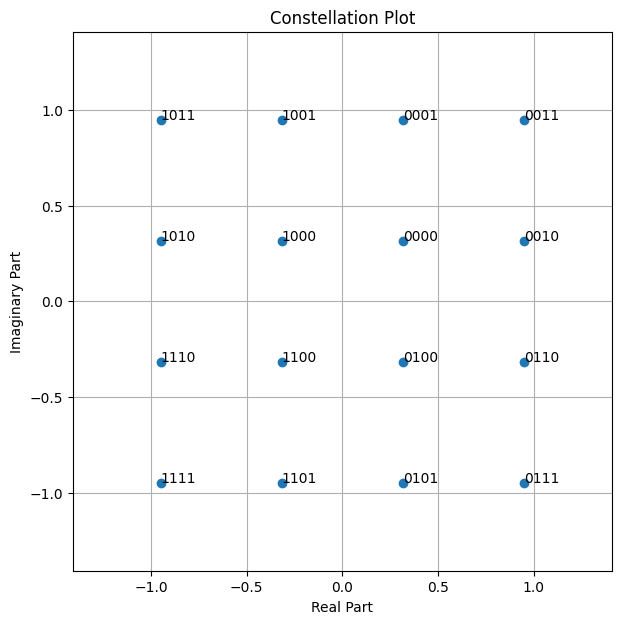

In [20]:
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol=4)
constellation.show();

### First Link-level Simulation

We can already build powerful code with a few simple commands.

As mentioned earlier, Sionna aims at hiding system complexity into blocks.
However, we still want to provide as much flexibility as possible.
Thus, most blocks have several choices of init parameters, but often the default choice is a good start.

**Tip**: the [API documentation](https://nvlabs.github.io/sionna/phy/api/phy.html) provides many helpful references and implementation details.

In [21]:
# system parameters
n_ldpc = 500 # LDPC codeword length 
k_ldpc = 250 # number of info bits per LDPC codeword
coderate = k_ldpc / n_ldpc
num_bits_per_symbol = 4 # number of bits mapped to one symbol (cf. QAM)

Often, several different algorithms are implemented, e.g., the demapper supports  *"true app"* demapping, but also *"max-log"* demapping.

The check-node (CN) update function of the LDPC BP decoder also supports multiple algorithms.

In [22]:
demapping_method = "app" # try "max-log"
cn_update = "boxplus" # try "boxplus-phy"

Let us initialize all required components for the given system parameters.

In [23]:
binary_source = sionna.phy.mapping.BinarySource()
encoder = sionna.phy.fec.ldpc.LDPC5GEncoder(k_ldpc, n_ldpc)
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
channel = sionna.phy.channel.AWGN()
demapper = sionna.phy.mapping.Demapper(demapping_method,
                                       constellation=constellation)
decoder = sionna.phy.fec.ldpc.LDPC5GDecoder(encoder,
                                            hard_out=True, cn_update=cn_update,
                                            num_iter=20)

We can now run the code in *eager mode*. This allows us to modify the structure at any time - you can try a different `batch_size` or a different SNR `ebno_db`.

In [24]:
# simulation parameters
batch_size = 1000
ebno_db = 4

# Generate a batch of random bit vectors
b = binary_source([batch_size, k_ldpc])

# Encode the bits using 5G LDPC code
print("Shape before encoding: ", b.shape)
c = encoder(b)
print("Shape after encoding: ", c.shape)

# Map bits to constellation symbols
x = mapper(c)
print("Shape after mapping: ", x.shape)

# Transmit over an AWGN channel at SNR 'ebno_db'
no = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
y = channel(x, no)
print("Shape after channel: ", y.shape)

# Demap to LLRs
llr = demapper(y, no)
print("Shape after demapping: ", llr.shape)

# LDPC decoding using 20 BP iterations
b_hat = decoder(llr)
print("Shape after decoding: ", b_hat.shape)

# calculate BERs
c_hat = (llr > 0.0).float()  # hard-decided bits before dec.
ber_uncoded = sionna.phy.utils.compute_ber(c, c_hat)

ber_coded = sionna.phy.utils.compute_ber(b, b_hat)

print("BER uncoded = {:.3f} at EbNo = {:.1f} dB".format(ber_uncoded, ebno_db))
print("BER after decoding = {:.3f} at EbNo = {:.1f} dB".format(ber_coded, ebno_db))
print("In total {} bits were simulated".format(b.numel()))

Shape before encoding:  torch.Size([1000, 250])


Shape after encoding:  torch.Size([1000, 500])
Shape after mapping:  torch.Size([1000, 125])
Shape after channel:  torch.Size([1000, 125])
Shape after demapping:  torch.Size([1000, 500])
Shape after decoding:  torch.Size([1000, 250])
BER uncoded = 0.120 at EbNo = 4.0 dB
BER after decoding = 0.009 at EbNo = 4.0 dB
In total 250000 bits were simulated


Just to summarize: we have simulated the transmission of 250,000 bits including higher-order modulation and channel coding!

But we can go even faster with `torch.compile`!

### Setting up the End-to-end Model

We now define a block that wraps the entire link-level simultaions into a single
callable which more convenient for training and Monte-Carlo simulations.

We simulate the transmission over a time-varying multi-path channel (the *TDL-A* model from 3GPP TR38.901).
For this, OFDM and a *conventional* bit-interleaved coded modulation (BICM) scheme with higher order modulation is used.
The information bits are protected by a 5G-compliant LDPC code.

*Remark*: Due to the large number of parameters, we define them as dictionary.

In [25]:
class e2e_model(sionna.phy.Block):
    """Example model for end-to-end link-level simulations.
    
    Parameters
    ----------
    params: dict
        A dictionary defining the system parameters.

    Input
    -----
    batch_size: int or torch.int
        The batch_sizeused for the simulation.

    ebno_db: float or torch.float
        A float defining the simulation SNR.

    Output
    ------
    (b, b_hat): 
        Tuple:

    b: torch.float
        A tensor of shape `[batch_size, k]` containing the transmitted
        information bits.

    b_hat: torch.float
        A tensor of shape `[batch_size, k]` containing the receiver's
        estimate of the transmitted information bits.
    """
    def __init__(self,
                params):
        super().__init__()

        # Define an OFDM Resource Grid Object
        self.rg = sionna.phy.ofdm.ResourceGrid(
                            num_ofdm_symbols=params["num_ofdm_symbols"],
                            fft_size=params["fft_size"],
                            subcarrier_spacing=params["subcarrier_spacing"],
                            num_tx=1,
                            num_streams_per_tx=1,
                            cyclic_prefix_length=params["cyclic_prefix_length"],
                            pilot_pattern="kronecker",
                            pilot_ofdm_symbol_indices=params["pilot_ofdm_symbol_indices"])
              
        # Create a Stream Management object        
        self.sm = sionna.phy.mimo.StreamManagement(rx_tx_association=np.array([[1]]),
                                                   num_streams_per_tx=1)
        
        self.coderate = params["coderate"]
        self.num_bits_per_symbol = params["num_bits_per_symbol"]
        self.n = int(self.rg.num_data_symbols*self.num_bits_per_symbol) 
        self.k = int(self.n*coderate)         

        # Init layers
        self.binary_source = sionna.phy.mapping.BinarySource()
        self.encoder = sionna.phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.interleaver = sionna.phy.fec.interleaving.RowColumnInterleaver(
                                        row_depth=self.num_bits_per_symbol)
        self.deinterleaver = sionna.phy.fec.interleaving.Deinterleaver(self.interleaver)
        self.mapper = sionna.phy.mapping.Mapper("qam", self.num_bits_per_symbol)
        self.rg_mapper = sionna.phy.ofdm.ResourceGridMapper(self.rg)
        self.tdl = sionna.phy.channel.tr38901.TDL(
                           model="A",
                           delay_spread=params["delay_spread"],
                           carrier_frequency=params["carrier_frequency"],
                           min_speed=params["min_speed"],
                           max_speed=params["max_speed"])
        
        self.channel = sionna.phy.channel.OFDMChannel(self.tdl, self.rg, add_awgn=True, normalize_channel=True)
        self.ls_est = sionna.phy.ofdm.LSChannelEstimator(self.rg, interpolation_type="nn")
        self.lmmse_equ = sionna.phy.ofdm.LMMSEEqualizer(self.rg, self.sm)
        self.demapper = sionna.phy.mapping.Demapper(params["demapping_method"],
                                                "qam", self.num_bits_per_symbol)
        self.decoder = sionna.phy.fec.ldpc.LDPC5GDecoder(self.encoder,
                                                    hard_out=True,
                                                    cn_update=params["cn_update"],
                                                    num_iter=params["bp_iter"])

        print("Number of pilots: {}".format(self.rg.num_pilot_symbols))        
        print("Number of data symbols: {}".format(self.rg.num_data_symbols))
        print("Number of resource elements: {}".format(
                                    self.rg.num_resource_elements))

        print("Pilot overhead: {:.2f}%".format(
                                    self.rg.num_pilot_symbols /
                                    self.rg.num_resource_elements*100))

        print("Cyclic prefix overhead: {:.2f}%".format(
                                    params["cyclic_prefix_length"] /
                                    (params["cyclic_prefix_length"]
                                    +params["fft_size"])*100))

        print("Each frame contains {} information bits".format(self.k))

    def call(self, batch_size, ebno_db):

        # Generate a batch of random bit vectors
        # We need two dummy dimension representing the number of
        # transmitters and streams per transmitter, respectively.
        b = self.binary_source([batch_size, 1, 1, self.k])

        # Encode the bits using the all-zero dummy encoder
        c = self.encoder(b)

        # Interleave the bits before mapping (BICM)
        c_int = self.interleaver(c)

        # Map bits to constellation symbols
        s = self.mapper(c_int)

        # Map symbols onto OFDM ressource grid
        x_rg = self.rg_mapper(s)

        # Transmit over noisy multi-path channel 
        no = sionna.phy.utils.ebnodb2no(ebno_db, self.num_bits_per_symbol, self.coderate, self.rg)
        y = self.channel(x_rg, no) 

        # LS Channel estimation with nearest pilot interpolation
        h_hat, err_var = self.ls_est (y, no)

        # LMMSE Equalization
        x_hat, no_eff = self.lmmse_equ(y, h_hat, err_var, no)

        # Demap to LLRs
        llr = self.demapper(x_hat, no_eff)

        # Deinterleave before decoding
        llr_int = self.deinterleaver(llr)

        # Decode
        b_hat = self.decoder(llr_int) 

        # number of simulated bits
        nb_bits = batch_size*self.k

        # transmitted bits and the receiver's estimate after decoding
        return b, b_hat

Let us define the system parameters for our simulation as dictionary:

In [26]:
sys_params = {
    # Channel
    "carrier_frequency" : 3.5e9,
    "delay_spread" : 100e-9,
    "min_speed" : 3,
    "max_speed" : 3,
    "tdl_model" : "A",

    # OFDM
    "fft_size" : 256,
    "subcarrier_spacing" : 30e3,
    "num_ofdm_symbols" : 14,
    "cyclic_prefix_length" : 16,
    "pilot_ofdm_symbol_indices" : [2, 11],

    # Code & Modulation
    "coderate" : 0.5,
    "num_bits_per_symbol" : 4,
    "demapping_method" : "app",
    "cn_update" : "boxplus",
    "bp_iter" : 20
}

...and initialize the model:

In [27]:
model = e2e_model(sys_params)

Number of pilots: 512
Number of data symbols: 3072
Number of resource elements: 3584
Pilot overhead: 14.29%
Cyclic prefix overhead: 5.88%
Each frame contains 6144 information bits


As before, we can simply *call* the model to simulate the BER for the given simulation parameters.

In [28]:
#simulation parameters
ebno_db = 10
batch_size = 200

# and call the model
b, b_hat = model(batch_size, ebno_db)

ber = sionna.phy.utils.compute_ber(b, b_hat)
nb_bits = b.numel()

print("BER: {:.4} at Eb/No of {} dB and {} simulated bits".format(ber, ebno_db, nb_bits))

BER: 0.002491 at Eb/No of 10 dB and 1228800 simulated bits


### Run some Throughput Tests (Compile Mode)

Sionna is not just an easy-to-use library, but also incredibly fast.
Let us measure the throughput of the model defined above.

We compare *eager* and different *compiled* execution modes (see [PyTorch Doc](https://docs.pytorch.org/tutorials/intermediate/torch_compile_tutorial.html) for details).

**Tip**: change the `batch_size` to see how the batch parallelism enhances the throughput.
Depending on your machine, the `batch_size` may be too large.

In [29]:
import time
torch.compiler.reset()

batch_size = 200
ebno_db = 5.0  # evaluate SNR point
repetitions = 10  # repetitions for throughput measurement
warmup_iterations = 3  # warmup iterations after compilation

def timed(fn):
    """Time a function using CUDA events for GPU accuracy."""
    if torch.cuda.is_available():
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        result = fn()
        end.record()
        torch.cuda.synchronize()
        elapsed_ms = start.elapsed_time(end)  # milliseconds
        return result, elapsed_ms / 1000  # return seconds
    else:
        start = time.perf_counter()
        result = fn()
        end = time.perf_counter()
        return result, end - start

def measure_compile_time(run_fn, batch_size, ebno_db):
    """Measure the time for first call (includes compilation for compiled models)."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()
    result = run_fn(batch_size, ebno_db)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()
    return result, end - start

def benchmark(run_fn, batch_size, ebno_db, repetitions=10, warmup=3):
    """Benchmark throughput with proper warmup and CUDA event timing."""
    # Additional warmup after compilation
    for _ in range(warmup):
        run_fn(batch_size, ebno_db)
    
    # Timed iterations
    times = []
    for i in range(repetitions):
        (b, b_hat), elapsed = timed(lambda: run_fn(batch_size, ebno_db))
        times.append(elapsed)
    
    # Use median for robustness against outliers
    median_time = np.median(times)
    throughput = b.numel() / median_time  # bits per second
    
    return throughput, times

# Eager mode - default PyTorch execution
def run_eager(batch_size, ebno_db):
    return model(batch_size, ebno_db)

# Measure eager "compile" time (baseline - no actual compilation)
print("Measuring eager mode first-call time...")
_, compile_time_eager = measure_compile_time(run_eager, batch_size, ebno_db)

# Create and measure compile time for reduce-overhead mode
print("Compiling reduce-overhead mode...")
run_reduce_overhead = torch.compile(model, mode="reduce-overhead")
_, compile_time_reduce = measure_compile_time(run_reduce_overhead, batch_size, ebno_db)

# Create and measure compile time for max-autotune mode
print("Compiling max-autotune mode (this may take a while)...")
run_max_autotune = torch.compile(model, mode="max-autotune")
_, compile_time_autotune = measure_compile_time(run_max_autotune, batch_size, ebno_db)

# Compilation time results
print("=" * 60)
print("COMPILATION TIME (first call)")
print("=" * 60)
print(f"Eager (no compilation):        {compile_time_eager:8.2f} s")
print(f"reduce-overhead compilation:   {compile_time_reduce:8.2f} s")
print(f"max-autotune compilation:      {compile_time_autotune:8.2f} s")

# Run throughput benchmarks
print("\n" + "=" * 60)
print("INFERENCE THROUGHPUT (after compilation)")
print("=" * 60)

print("Benchmarking eager mode...")
throughput_eager, times_eager = benchmark(run_eager, batch_size, ebno_db, 
                                           repetitions=repetitions, warmup=1)

print("Benchmarking reduce-overhead mode...")
throughput_reduce_overhead, times_reduce = benchmark(run_reduce_overhead, batch_size, ebno_db,
                                                      repetitions=repetitions, warmup=warmup_iterations)

print("Benchmarking max-autotune mode...")
throughput_max_autotune, times_autotune = benchmark(run_max_autotune, batch_size, ebno_db,
                                                     repetitions=repetitions, warmup=warmup_iterations)

# Throughput results
print(f"Eager mode:                    {throughput_eager/1e6:8.2f} Mb/s")
print(f"reduce-overhead:               {throughput_reduce_overhead/1e6:8.2f} Mb/s")
print(f"max-autotune:                  {throughput_max_autotune/1e6:8.2f} Mb/s")

# Speedups
print("\n" + "=" * 60)
print("SPEEDUP vs EAGER")
print("=" * 60)
speedup_reduce = throughput_reduce_overhead / throughput_eager
speedup_autotune = throughput_max_autotune / throughput_eager
print(f"reduce-overhead:               {speedup_reduce:8.2f}x")
print(f"max-autotune:                  {speedup_autotune:8.2f}x")

# Break-even analysis: how many inferences to amortize compilation cost
print("\n" + "=" * 60)
print("BREAK-EVEN ANALYSIS")
print("=" * 60)
time_per_inference_eager = np.median(times_eager)
time_per_inference_reduce = np.median(times_reduce)
time_per_inference_autotune = np.median(times_autotune)

if time_per_inference_eager > time_per_inference_reduce:
    breakeven_reduce = compile_time_reduce / (time_per_inference_eager - time_per_inference_reduce)
    print(f"reduce-overhead breaks even after: {breakeven_reduce:.0f} inferences")
else:
    print(f"reduce-overhead: no speedup (eager is faster)")

if time_per_inference_eager > time_per_inference_autotune:
    breakeven_autotune = compile_time_autotune / (time_per_inference_eager - time_per_inference_autotune)
    print(f"max-autotune breaks even after:    {breakeven_autotune:.0f} inferences")
else:
    print(f"max-autotune: no speedup (eager is faster)")

Measuring eager mode first-call time...
Compiling reduce-overhead mode...


/home/mliu/anaconda3/envs/sionna/lib/python3.11/site-packages/torch/_inductor/lowering.py:2156: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


Compiling max-autotune mode (this may take a while)...
COMPILATION TIME (first call)
Eager (no compilation):            0.35 s
reduce-overhead compilation:      10.82 s
max-autotune compilation:         23.12 s

INFERENCE THROUGHPUT (after compilation)
Benchmarking eager mode...
Benchmarking reduce-overhead mode...
Benchmarking max-autotune mode...
Eager mode:                        3.51 Mb/s
reduce-overhead:                  14.71 Mb/s
max-autotune:                     18.56 Mb/s

SPEEDUP vs EAGER
reduce-overhead:                   4.19x
max-autotune:                      5.28x

BREAK-EVEN ANALYSIS
reduce-overhead breaks even after: 41 inferences
max-autotune breaks even after:    82 inferences


You can ignore warnings about missing support for complex numbers as this is a
known limitation. The performance improvements of compilation are very important

### Bit-Error Rate (BER) Monte-Carlo Simulations

Monte-Carlo simulations are omnipresent in todays communications research and development.
Due its performant implementation, Sionna can be directly used to simulate BER at a performance that competes with compiled languages -- but still keeps the flexibility of a script language.

In [30]:
ebno_dbs = np.arange(0, 15, 1.)
batch_size = 200 # reduce in case you receive an out-of-memory (OOM) error

max_mc_iter = 1000 # max number of Monte-Carlo iterations before going to next SNR point
num_target_block_errors = 500 # continue with next SNR point after target number of block errors

ber_mc,_ = sionna.phy.utils.sim_ber(model,
                                    ebno_dbs,
                                    batch_size=batch_size, 
                                    num_target_block_errors=num_target_block_errors,
                                    max_mc_iter=max_mc_iter,
                                    compile_mode="reduce-overhead", # configure the compilation mode here
                                    verbose=True) # print status and summary

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.4343e-01 | 1.0000e+00 |     1266023 |     3686400 |          600 |         600 |         7.4 |reached target block errors
      1.0 | 3.2036e-01 | 1.0000e+00 |     1180985 |     3686400 |          600 |         600 |         0.3 |reached target block errors
      2.0 | 2.9804e-01 | 1.0000e+00 |     1098682 |     3686400 |          600 |         600 |         0.3 |reached target block errors
      3.0 | 2.7313e-01 | 1.0000e+00 |     1006855 |     3686400 |          600 |         600 |         0.3 |reached target block errors
      4.0 | 2.4794e-01 | 1.0000e+00 |      914017 |     3686400 |          600 |         600 |         0.3 |reached target block errors
      5.0 | 2.1892e-01 | 1.0000e+00 |      807036 |     3686400 |

Let's look at the results:

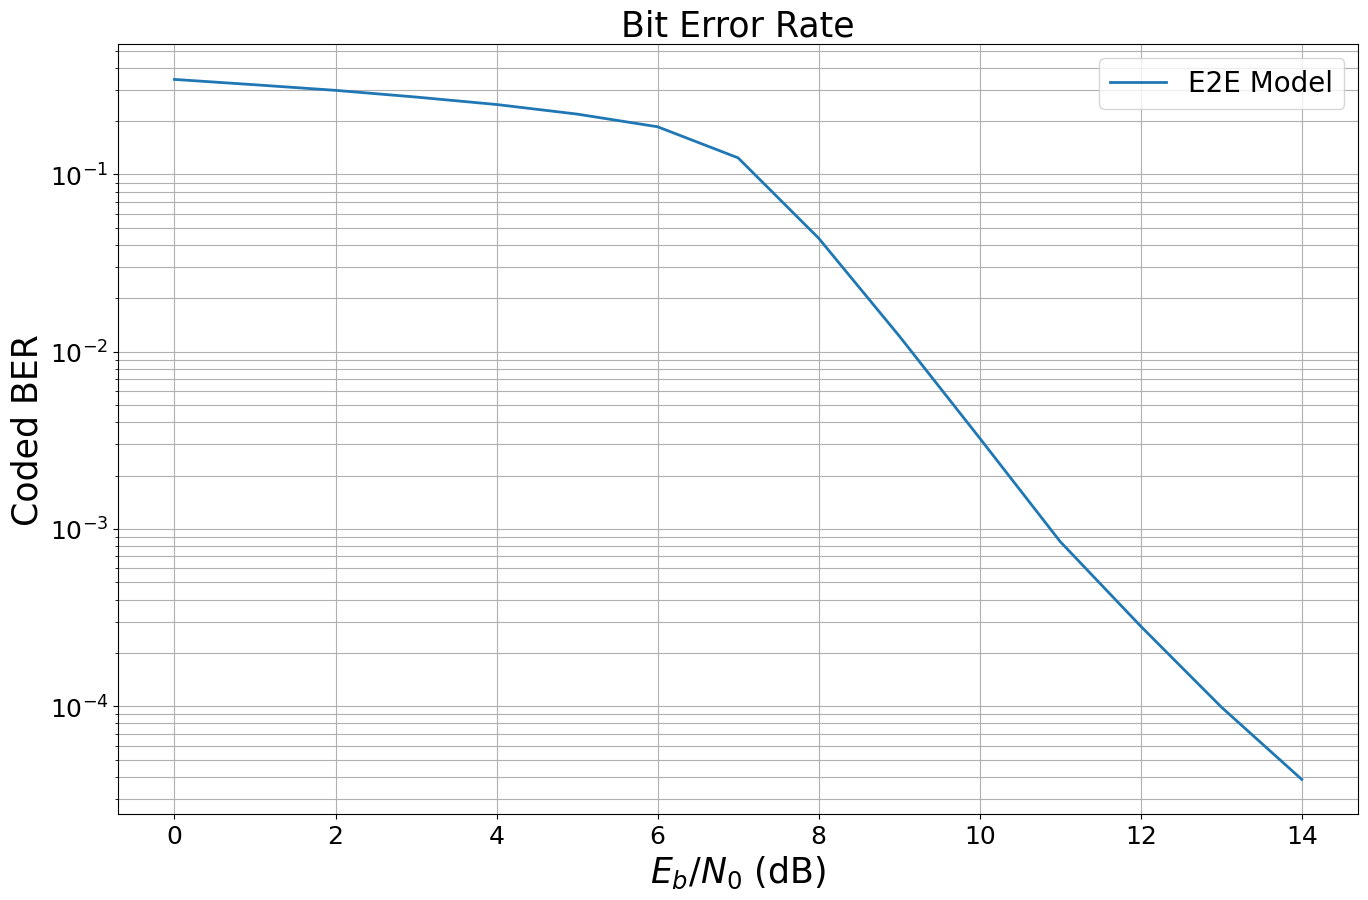

In [31]:
sionna.phy.utils.plot_ber(ebno_dbs,
                          ber_mc.cpu(),
                          legend="E2E Model",
                          ylabel="Coded BER");

### Conclusion

We hope you are excited about Sionna - there is much more to be discovered. See the [available tutorials](https://nvlabs.github.io/sionna/phy/tutorials/index.html) for more advanced examples.

And if something is still missing - the project is [open-source](https://github.com/nvlabs/sionna/):  you can modify, add, and extend any component at any time.